In [1]:
# ! pip install -q datasets
# ! pip install -q transformers
# ! pip install -q sentencepiece
# ! pip install protobuf tiktoken



In [2]:
import pandas as pd

In [3]:
# read the dataset
df = pd.read_csv("./train.csv")

In [4]:
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


In [5]:
# Let's try to understand the dataset from high level
df.describe(include="str")

,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,37d61fd2272659b1,component composite coating,composition,H01
freq,1,152,24,2186


In [6]:
# Let's create a new field called 'input'
df["input"] = 'TEXT1: ' + df.context + '; TEXT2: '+ df.target + '; ANC1: '+ df.anchor

In [7]:
df.input.head(10)

0    TEXT1: A47; TEXT2: abatement of pollution; ANC...
1    TEXT1: A47; TEXT2: act of abating; ANC1: abate...
2    TEXT1: A47; TEXT2: active catalyst; ANC1: abat...
3    TEXT1: A47; TEXT2: eliminating process; ANC1: ...
4    TEXT1: A47; TEXT2: forest region; ANC1: abatement
5    TEXT1: A47; TEXT2: greenhouse gases; ANC1: aba...
6    TEXT1: A47; TEXT2: increased rate; ANC1: abate...
7    TEXT1: A47; TEXT2: measurement level; ANC1: ab...
8    TEXT1: A47; TEXT2: minimising sounds; ANC1: ab...
9    TEXT1: A47; TEXT2: mixing core materials; ANC1...
Name: input, dtype: str

Convert pandas dataframe into huggingface dataset

In [8]:
from datasets import Dataset, DatasetDict

ds = Dataset.from_pandas(df)

In [9]:
ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
    num_rows: 36473
})

- Tokenization: convert each text up into words (sometimes subwords)
- Numericalization: Convert each word (or token) into a number

In [10]:
model_nm =  'microsoft/deberta-v3-small'

`Autotokenizer` will create a tokenizer appropriate for a given model

In [11]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
tokz = AutoTokenizer.from_pretrained(model_nm)

In [12]:
tokz.tokenize('Hello! this is a hilarious news for the psychologist!')

['▁Hello',
 '!',
 '▁this',
 '▁is',
 '▁a',
 '▁hilarious',
 '▁news',
 '▁for',
 '▁the',
 '▁psychologist',
 '!']

Uknown words will split into pieces. The start of a new word is represented by `_`

In [13]:
tokz.tokenize('The maghbanierly is whiteflur than jerrky')

['▁The',
 '▁mag',
 'h',
 'bani',
 'erly',
 '▁is',
 '▁white',
 'flu',
 'r',
 '▁than',
 '▁jer',
 'r',
 'ky']

In [16]:
#total vocabolary length
len(tokz.vocab)

128001

function for tokenize our input

In [17]:
def tok_func(x): return tokz(x['input'])

In [18]:
tok_ds = ds.map(tok_func, batched=True)

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

In [22]:
#a sample row
row = tok_ds[0]
row

{'id': '37d61fd2272659b1',
 'anchor': 'abatement',
 'target': 'abatement of pollution',
 'context': 'A47',
 'score': 0.5,
 'input': 'TEXT1: A47; TEXT2: abatement of pollution; ANC1: abatement',
 'input_ids': [1,
  54453,
  435,
  294,
  336,
  5753,
  346,
  54453,
  445,
  294,
  47284,
  265,
  6435,
  346,
  23702,
  435,
  294,
  47284,
  2],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

This adds a new item in our dataset called input_ids. For instance, here is the input and IDs for the first row of our data

In [23]:
row['input'], row['input_ids']

('TEXT1: A47; TEXT2: abatement of pollution; ANC1: abatement',
 [1,
  54453,
  435,
  294,
  336,
  5753,
  346,
  54453,
  445,
  294,
  47284,
  265,
  6435,
  346,
  23702,
  435,
  294,
  47284,
  2])

So, what are those IDs and where do they come from? The secret is that there's a list called vocab in the tokenizer which contains a unique integer for every possible token string. We can look them up like this, for instance to find the token for the word `of`:

In [32]:
{v: k for k, v in tokz.vocab.items()}[265]

'▁of'

In [33]:
tokz.vocab['▁of']

265

transformers expect labels name to be `labels`, but in our dataset, it is `score`. Let's change this

In [34]:
tok_ds = tok_ds.rename_columns({'score':'labels'})

### Test and Validation Set

In [35]:
eval_df = pd.read_csv('./test.csv')

In [36]:
eval_df.describe()

,id,anchor,target,context
count,36,36,36,36
unique,36,34,36,29
top,4112d61851461f60,el display,inorganic photoconductor drum,G02
freq,1,2,1,3


This is the test set. Possibly the most important idea in machine learning is that of having separate training, validation, and test data sets.

### Validation Set

To explain the motivation, let's start simple, and imagine we're trying to fit a model where the true relationship is this quadratic:

In [37]:
def f(x):
    return -3 * x**2 + 2 * x + 20

Let's visualize this function in matplotlib

In [85]:
import numpy as np, matplotlib.pyplot as plt


def plot_function(f, min=-2.1, max=2.1, color="r", y_lim=None):
    x = np.linspace(min, max, 100)[:None]
    if y_lim:
        plt.ylim(y_lim)
    plt.plot(
        x,
        f(x),
        color,
    )

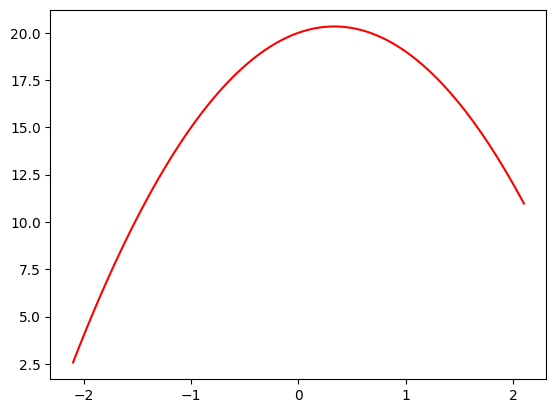

In [86]:
plot_function(f)

For instnace, perhaps we've measured the height above the ground of an object before and after some event. The measurements will have some random error. We can use numpy's random number generator to simulate that. We will use the `seed` when writing about simulations like this so that we see the same thing everytime

In [87]:
from numpy.random import normal, seed, uniform
np.random.seed(42)

In [88]:
def noise(x, scale):
    return normal(scale=scale, size=x.shape)

def add_noise(x, mul, add):
    return x * (1 + noise(x, mul) + noise(x, add))

let's use it to simulate some measurements evenly distributed over time

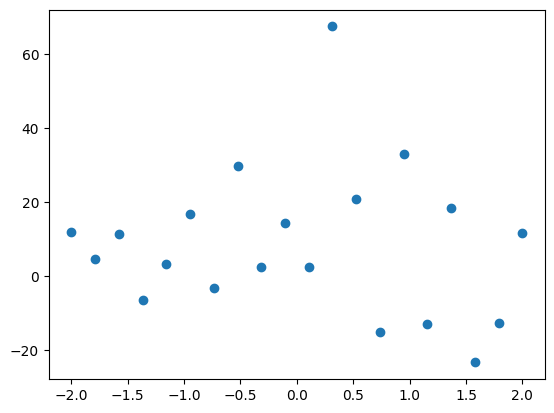

In [89]:
x = np.linspace(-2, 2, num=20)[:None]
y = add_noise(f(x), 0.2, 1.3)
plt.scatter(x,y)

In [149]:
print(x)

[-2.         -1.78947368 -1.57894737 -1.36842105 -1.15789474 -0.94736842
 -0.73684211 -0.52631579 -0.31578947 -0.10526316  0.10526316  0.31578947
  0.52631579  0.73684211  0.94736842  1.15789474  1.36842105  1.57894737
  1.78947368  2.        ]


Now let's see what happens if we underfit or overfit these predictions. To do that, we'll create a function that fits a polynomial of some degree (e.g. a line is degree 1, quadratic is degree 2, cubic is degree 3, etc)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# def plot_poly(degree):
#     model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
#     model.fit(x.reshape(-1, 1), y)
#     plt.scatter(x, y)
#     plot_function(lambda x: model.predict(x.reshape(-1, 1)),y_lim=(-15,40))

def plot_poly(degree):
    # Step 1: create model
    poly = PolynomialFeatures(degree)
    lin = LinearRegression()

    X_poly = poly.fit_transform(x.reshape(-1, 1))
    
    # Step 2: train
    lin.fit(X_poly, y)

    # Step 3: plot
    plt.scatter(x, y)

    def f(x_input):
        X_new = poly.transform(x_input.reshape(-1, 1))
        return lin.predict(X_new)

    plot_function(f, y_lim=(-15,40))

[[ 1.         -2.          4.        ]
 [ 1.         -1.78947368  3.20221607]
 [ 1.         -1.57894737  2.49307479]
 [ 1.         -1.36842105  1.87257618]
 [ 1.         -1.15789474  1.34072022]
 [ 1.         -0.94736842  0.89750693]
 [ 1.         -0.73684211  0.54293629]
 [ 1.         -0.52631579  0.27700831]
 [ 1.         -0.31578947  0.09972299]
 [ 1.         -0.10526316  0.01108033]
 [ 1.          0.10526316  0.01108033]
 [ 1.          0.31578947  0.09972299]
 [ 1.          0.52631579  0.27700831]
 [ 1.          0.73684211  0.54293629]
 [ 1.          0.94736842  0.89750693]
 [ 1.          1.15789474  1.34072022]
 [ 1.          1.36842105  1.87257618]
 [ 1.          1.57894737  2.49307479]
 [ 1.          1.78947368  3.20221607]
 [ 1.          2.          4.        ]]


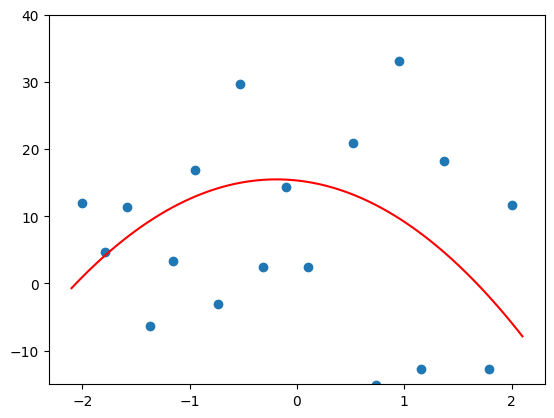

In [153]:
plot_poly(2)
